In [ ]:
!nvidia-smi

Sat May  9 10:17:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics roboflow opencv-python matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.4 MB/s eta 0:00:00


In [ ]:
import os
import glob
import shutil
from ultralytics import YOLO
from IPython.display import Image, display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="1qMLQSmFWmPxaBH8uadN")
project = rf.workspace("data-rjjjf").project("-bicycle-bus-car")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 'bicycle',-'bus',-'car'-1 in yolov8:: 100%|██████████| 12808/12808 [00:01<00:00, 6534.79it/s]


In [ ]:
print("Dataset location:", dataset.location)
print(os.listdir(dataset.location))

Dataset location: /content/'bicycle',-'bus',-'car'-1
['README.dataset.txt', 'train', 'test', 'data.yaml', 'valid', 'README.roboflow.txt']


In [ ]:
data_yaml_path = os.path.join(dataset.location, "data.yaml")

with open(data_yaml_path, "r") as f:
    print(f.read())

names:
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
nc: 8
roboflow:
  license: CC BY 4.0
  project: -bicycle-bus-car
  url: https://universe.roboflow.com/data-rjjjf/-bicycle-bus-car/dataset/1
  version: 1
  workspace: data-rjjjf
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
import os

print(os.listdir(dataset.location))

readme1 = os.path.join(dataset.location, "README.dataset.txt")
readme2 = os.path.join(dataset.location, "README.roboflow.txt")

if os.path.exists(readme1):
    print("===== README.dataset.txt =====")
    with open(readme1, "r") as f:
        print(f.read())

if os.path.exists(readme2):
    print("===== README.roboflow.txt =====")
    with open(readme2, "r") as f:
        print(f.read())

['README.dataset.txt', 'train', 'test', 'data.yaml', 'valid', 'README.roboflow.txt']
===== README.dataset.txt =====
# 'bicycle', 'bus', 'car' > 2024-03-01 12:00pm
https://universe.roboflow.com/data-rjjjf/-bicycle-bus-car

Provided by a Roboflow user
License: CC BY 4.0


===== README.roboflow.txt =====

'bicycle', 'bus', 'car' - v1 2024-03-01 12:00pm

This dataset was exported via roboflow.com on February 5, 2025 at 5:35 PM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The

In [ ]:
import glob
from collections import Counter

label_files = glob.glob(os.path.join(dataset.location, "train/labels/*.txt"))

class_counter = Counter()

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = parts[0]
                class_counter[class_id] += 1

print("Class counts:")
for cls, count in sorted(class_counter.items()):
    print(cls, count)

Class counts:
0 1371
1 793
2 3477
3 6144
4 1611
5 4133
6 560
7 763


In [ ]:
import os
import glob
import cv2
import random
import matplotlib.pyplot as plt

dataset_path = dataset.location
images_path = os.path.join(dataset_path, "train/images")
labels_path = os.path.join(dataset_path, "train/labels")

def show_samples_for_class(target_class_id, max_samples=5):
    label_files = glob.glob(os.path.join(labels_path, "*.txt"))
    selected = []

    for label_file in label_files:
        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) > 0 and parts[0] == str(target_class_id):
                selected.append(label_file)
                break

    selected = random.sample(selected, min(max_samples, len(selected)))

    plt.figure(figsize=(15, 5))

    for idx, label_file in enumerate(selected):
        image_name = os.path.basename(label_file).replace(".txt", ".jpg")
        image_path = os.path.join(images_path, image_name)

        if not os.path.exists(image_path):
            image_name = os.path.basename(label_file).replace(".txt", ".png")
            image_path = os.path.join(images_path, image_name)

        img = cv2.imread(image_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            class_id = parts[0]

            if class_id != str(target_class_id):
                continue

            x_center, y_center, box_w, box_h = map(float, parts[1:])

            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(
                img,
                f"class {class_id}",
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 0, 0),
                2
            )

        plt.subplot(1, max_samples, idx + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Class {target_class_id}")

    plt.show()

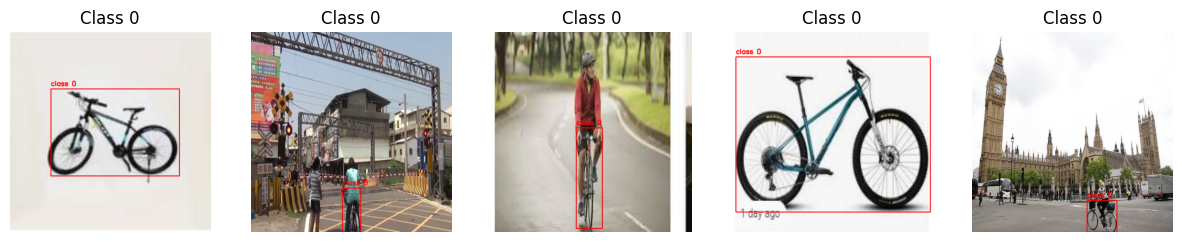

In [ ]:
show_samples_for_class(0)

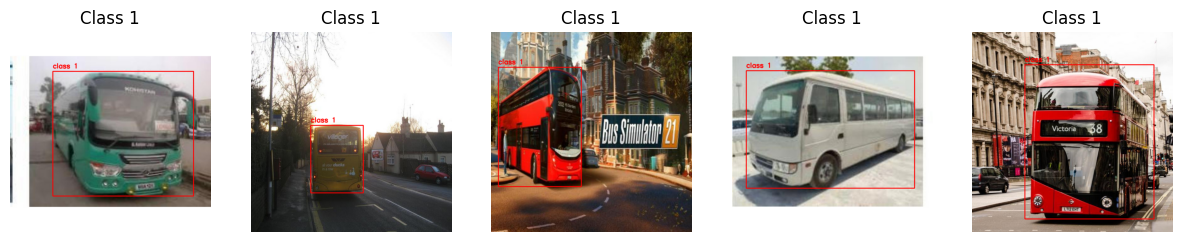

In [ ]:
show_samples_for_class(1)

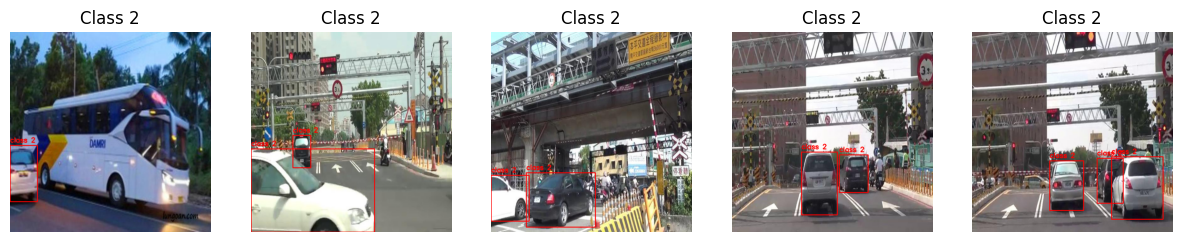

In [ ]:
show_samples_for_class(2)

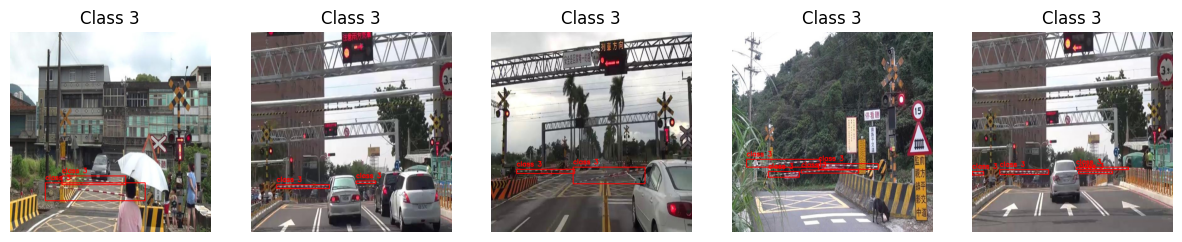

In [ ]:
show_samples_for_class(3)

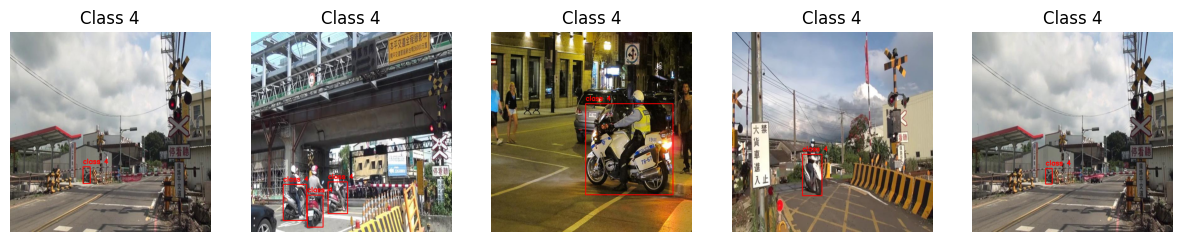

In [ ]:
show_samples_for_class(4)

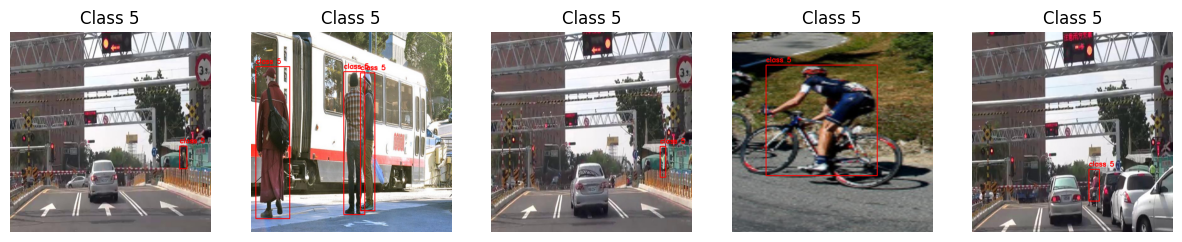

In [ ]:
show_samples_for_class(5)

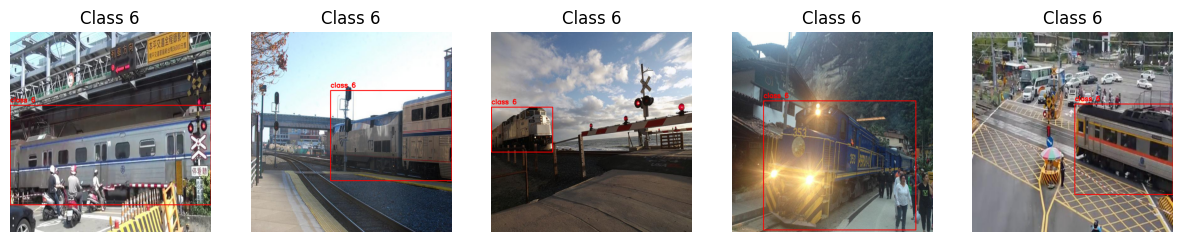

In [ ]:
show_samples_for_class(6)

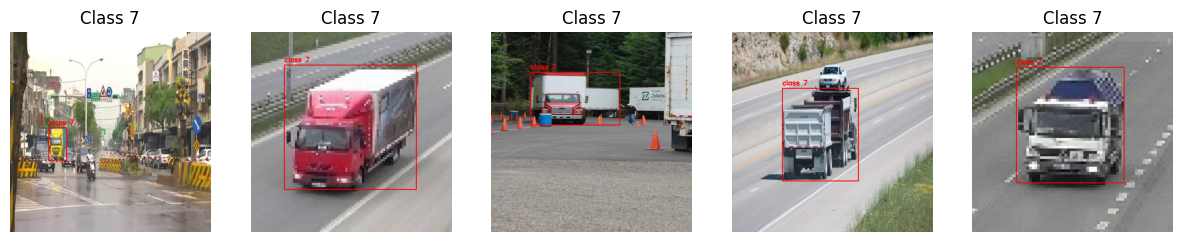

In [ ]:
show_samples_for_class(7)

In [ ]:
import os
import shutil
import glob
from pathlib import Path

original_dataset = dataset.location
filtered_dataset = "/content/vehicle_person_filtered_dataset"

# Original class mapping found from your dataset:
# 0 = bicycle
# 1 = bus
# 2 = car
# 3 = traffic barrier / unwanted
# 4 = motorcycle
# 5 = person
# 6 = train / unwanted
# 7 = truck

# New required classes:
# 0 = bicycle
# 1 = bus
# 2 = car
# 3 = motorcycle
# 4 = person
# 5 = truck

class_mapping = {
    "0": "0",  # bicycle
    "1": "1",  # bus
    "2": "2",  # car
    "4": "3",  # motorcycle
    "5": "4",  # person
    "7": "5",  # truck
}

splits = ["train", "valid", "test"]

# Remove old filtered dataset if exists
if os.path.exists(filtered_dataset):
    shutil.rmtree(filtered_dataset)

# Create folders
for split in splits:
    os.makedirs(f"{filtered_dataset}/{split}/images", exist_ok=True)
    os.makedirs(f"{filtered_dataset}/{split}/labels", exist_ok=True)

def find_image_file(image_dir, stem):
    extensions = [".jpg", ".jpeg", ".png", ".webp"]
    for ext in extensions:
        path = os.path.join(image_dir, stem + ext)
        if os.path.exists(path):
            return path
    return None

for split in splits:
    old_label_dir = os.path.join(original_dataset, split, "labels")
    old_image_dir = os.path.join(original_dataset, split, "images")

    new_label_dir = os.path.join(filtered_dataset, split, "labels")
    new_image_dir = os.path.join(filtered_dataset, split, "images")

    label_files = glob.glob(os.path.join(old_label_dir, "*.txt"))

    copied_count = 0

    for label_file in label_files:
        with open(label_file, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            old_class_id = parts[0]

            if old_class_id in class_mapping:
                parts[0] = class_mapping[old_class_id]
                new_lines.append(" ".join(parts) + "\n")

        # Copy only images that contain required vehicle/person classes
        if len(new_lines) > 0:
            stem = Path(label_file).stem
            image_file = find_image_file(old_image_dir, stem)

            if image_file is not None:
                shutil.copy(
                    image_file,
                    os.path.join(new_image_dir, os.path.basename(image_file))
                )

                new_label_path = os.path.join(new_label_dir, os.path.basename(label_file))
                with open(new_label_path, "w") as f:
                    f.writelines(new_lines)

                copied_count += 1

    print(f"{split}: copied {copied_count} images")

print("Filtered vehicle + person dataset created:", filtered_dataset)

train: copied 4539 images
valid: copied 559 images
test: copied 567 images
Filtered vehicle + person dataset created: /content/vehicle_person_filtered_dataset


In [ ]:
import yaml

vehicle_person_data_yaml = {
    "train": "/content/vehicle_person_filtered_dataset/train/images",
    "val": "/content/vehicle_person_filtered_dataset/valid/images",
    "test": "/content/vehicle_person_filtered_dataset/test/images",
    "nc": 6,
    "names": [
        "bicycle",
        "bus",
        "car",
        "motorcycle",
        "person",
        "truck"
    ]
}

data_yaml_path = "/content/vehicle_person_filtered_dataset/data.yaml"

with open(data_yaml_path, "w") as f:
    yaml.dump(vehicle_person_data_yaml, f, sort_keys=False)

with open(data_yaml_path, "r") as f:
    print(f.read())

train: /content/vehicle_person_filtered_dataset/train/images
val: /content/vehicle_person_filtered_dataset/valid/images
test: /content/vehicle_person_filtered_dataset/test/images
nc: 6
names:
- bicycle
- bus
- car
- motorcycle
- person
- truck



In [ ]:
from collections import Counter
import glob
import os

label_files = glob.glob("/content/vehicle_person_filtered_dataset/train/labels/*.txt")

class_counter = Counter()

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 0:
                class_counter[parts[0]] += 1

class_names = {
    "0": "bicycle",
    "1": "bus",
    "2": "car",
    "3": "motorcycle",
    "4": "person",
    "5": "truck"
}

print("Filtered training class counts:")
for cls_id, count in sorted(class_counter.items()):
    print(cls_id, class_names[cls_id], count)

Filtered training class counts:
0 bicycle 1371
1 bus 793
2 car 3477
3 motorcycle 1611
4 person 4133
5 truck 763


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer="auto",
    patience=10,
    project="/content/vehicle_person_detection_training",
    name="vehicle_detector"
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicle_person_filtered_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

In [ ]:
import shutil

best_model_path = "/content/vehicle_person_detection_training/vehicle_detector/weights/best.pt"
final_model_path = "/content/vehicle_detector.pt"

shutil.copy(best_model_path, final_model_path)

print("Final retrained model saved:", final_model_path)

Final retrained model saved: /content/vehicle_detector.pt


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/vehicle_detector.pt")

metrics = model.val(
    data=data_yaml_path,
    imgsz=640,
    batch=16
)

print(metrics)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1768.3±695.1 MB/s, size: 73.8 KB)
val: Scanning /content/vehicle_person_filtered_dataset/valid/labels.cache... 559 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 559/559 156.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.4it/s 6.5s
                   all        559       1425      0.919      0.923      0.954       0.77
               bicycle        133        169      0.944      0.901      0.947      0.732
                   bus         99        121      0.929      0.934      0.969      0.813
                   car        195        370      0.924      0.957      0.979      0.862
            motorcycle        102        166      0.893      0.959      0.967      0.786
                person  

Saving pp.jpg to pp.jpg

image 1/1 /content/pp.jpg: 384x640 2 cars, 3 persons, 64.9ms
Speed: 3.5ms preprocess, 64.9ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


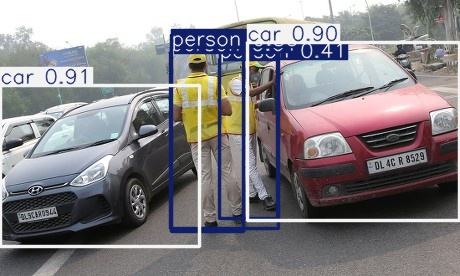

In [ ]:
from google.colab import files
import glob
from IPython.display import Image, display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

model = YOLO("/content/vehicle_detector.pt")

results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)

save_dir = str(results[0].save_dir)

predicted_images = glob.glob(save_dir + "/*.jpg") + glob.glob(save_dir + "/*.png")

display(Image(filename=predicted_images[-1]))

In [ ]:
from google.colab import files

files.download("/content/vehicle_detector.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>